# Pretrained vision SAEs: patches, concepts, and witnesses

Prisma CLIP ViT-B/32 and SAEV DINOv2 ViT-B/14 with registers.
200 training images select coordinates and queries; 100 test
images measure retrieval. Closure describes the full 300-image
context. Coordinate indices are never aligned across models.
This notebook needs source and experimental data only.

In [1]:
from pathlib import Path
import sys
import json
root = Path.cwd()
while not (root / 'src/lattmc/vision').is_dir():
    if root == root.parent:
        raise RuntimeError('Open within this repository')
    root = root.parent
sys.path.insert(0, str(root / 'src'))
evidence = root / 'vision_tokens/patch_contexts'

## Verify saved activations and exact concepts

The verifier checks full sparse-code caches, source pixels,
all 80 vector queries, 20 downset descriptions, and six
identical-pixel interventions. Native backbone and full SAE
recomputations are available with `--native` in the CLI.
The SAEV adapter preserves the old checkpoint encoder formula:
`relu((x - b_dec) @ W_enc + b_enc)`. Its published training
mean and scalar are retained with symmetric clipping.

In [2]:
from lattmc.vision.patch_verify_codexgen import verify
for name in ['prisma', 'saev']:
    verify(name)
    path = evidence / name / 'results'
    result = json.loads((path / 'extraction_codexgen.json')
                        .read_text())
    print(name, result['metrics'])

{
  "model": "prisma",
  "cached_images": 300,
  "cached_sites": 14700,
  "vector_queries": 40,
  "downset_concepts": 10,
  "identical_pixel_cases": 3,
  "native": null
}


prisma {'train': {'r2': 0.9851086810038509, 'mean_l0': 1408.6368408203125, 'images': 200, 'sites': 49}, 'test': {'r2': 0.9850327954457708, 'mean_l0': 1410.74853515625, 'images': 100, 'sites': 49}}


{
  "model": "saev",
  "cached_images": 300,
  "cached_sites": 76800,
  "vector_queries": 40,
  "downset_concepts": 10,
  "identical_pixel_cases": 3,
  "native": null
}


saev {'train': {'r2': 0.9297626460183166, 'mean_l0': 724.0580444335938, 'images': 200, 'sites': 256}, 'test': {'r2': 0.9295269327434859, 'mean_l0': 726.8712768554688, 'images': 100, 'sites': 256}}


## Meet, join, and common patch witnesses

Green cells satisfy every query coordinate at one token.
Heatmap values are activation / join threshold, clipped to
the display range [0, 2]. Cyan boxes mark the strongest common
response. These are contextual token responses, not masks.
Displayed images are the two highest-ranked test exemplars
for each fixed training query; they are illustrative selections.

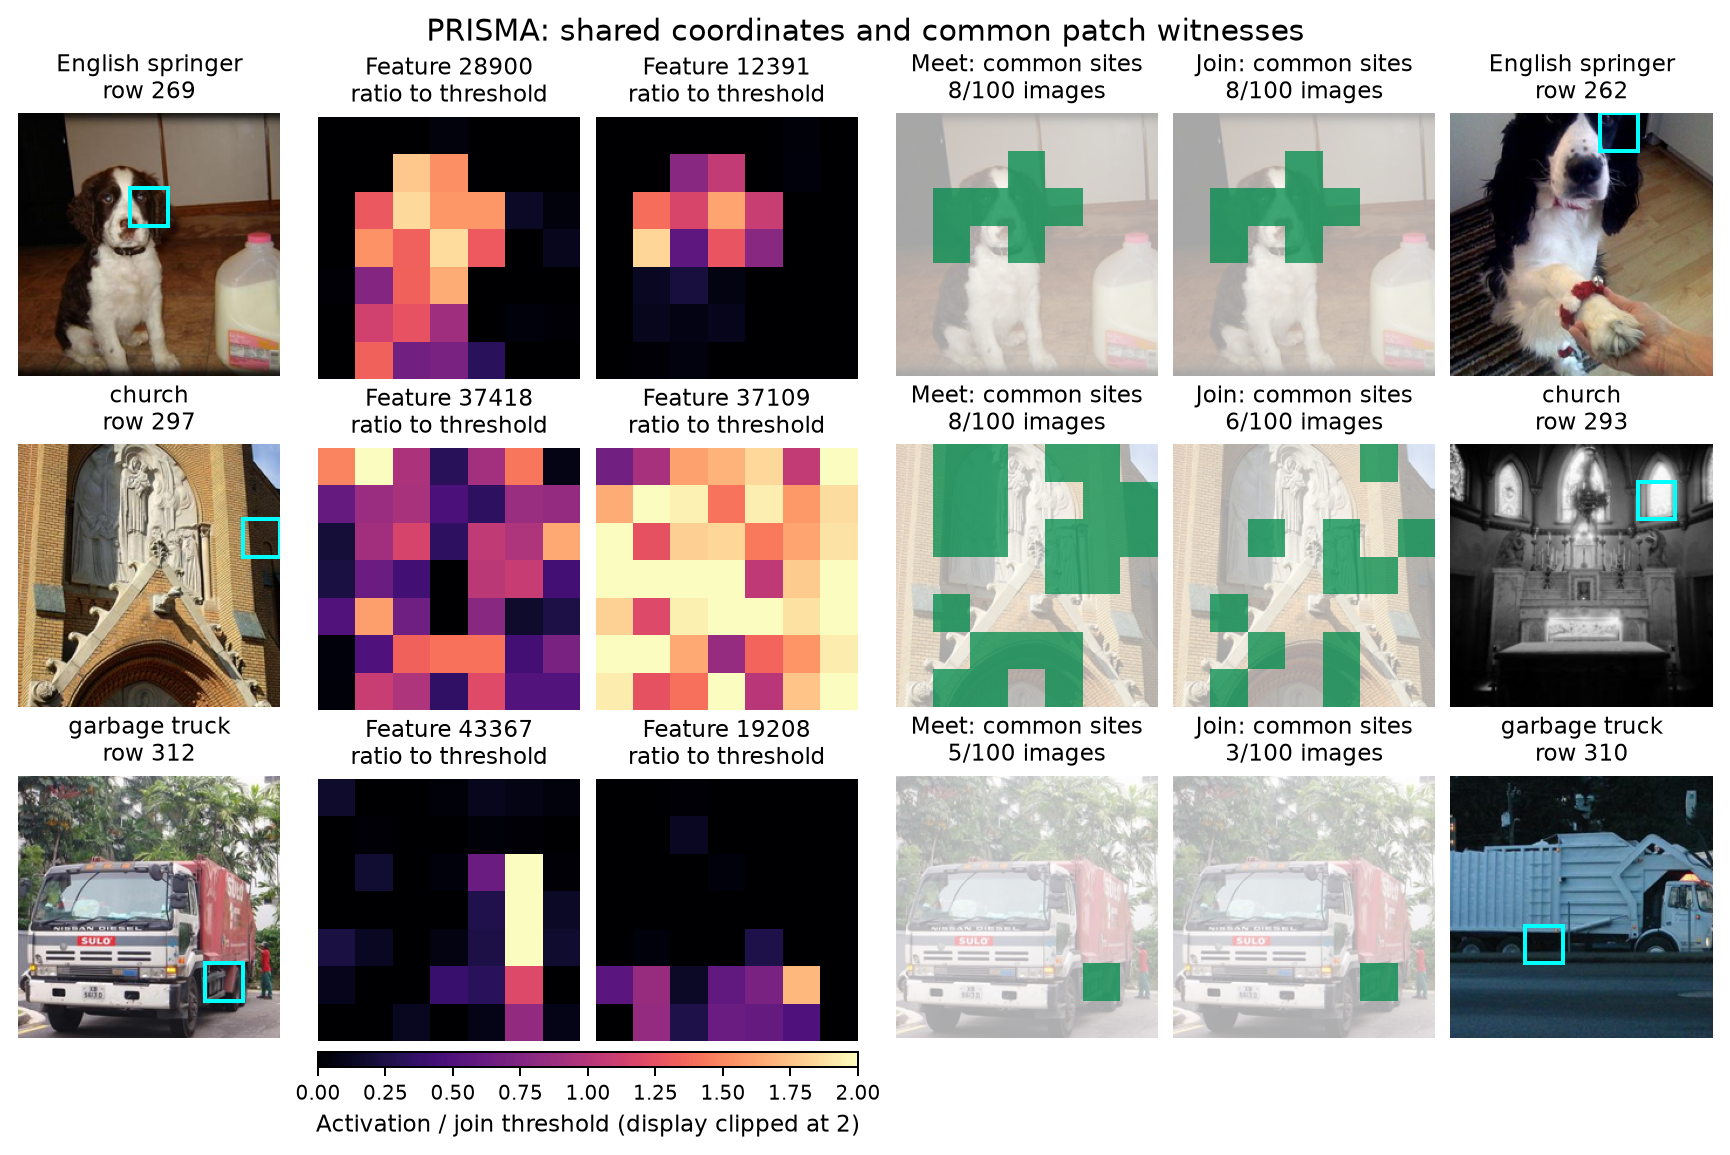

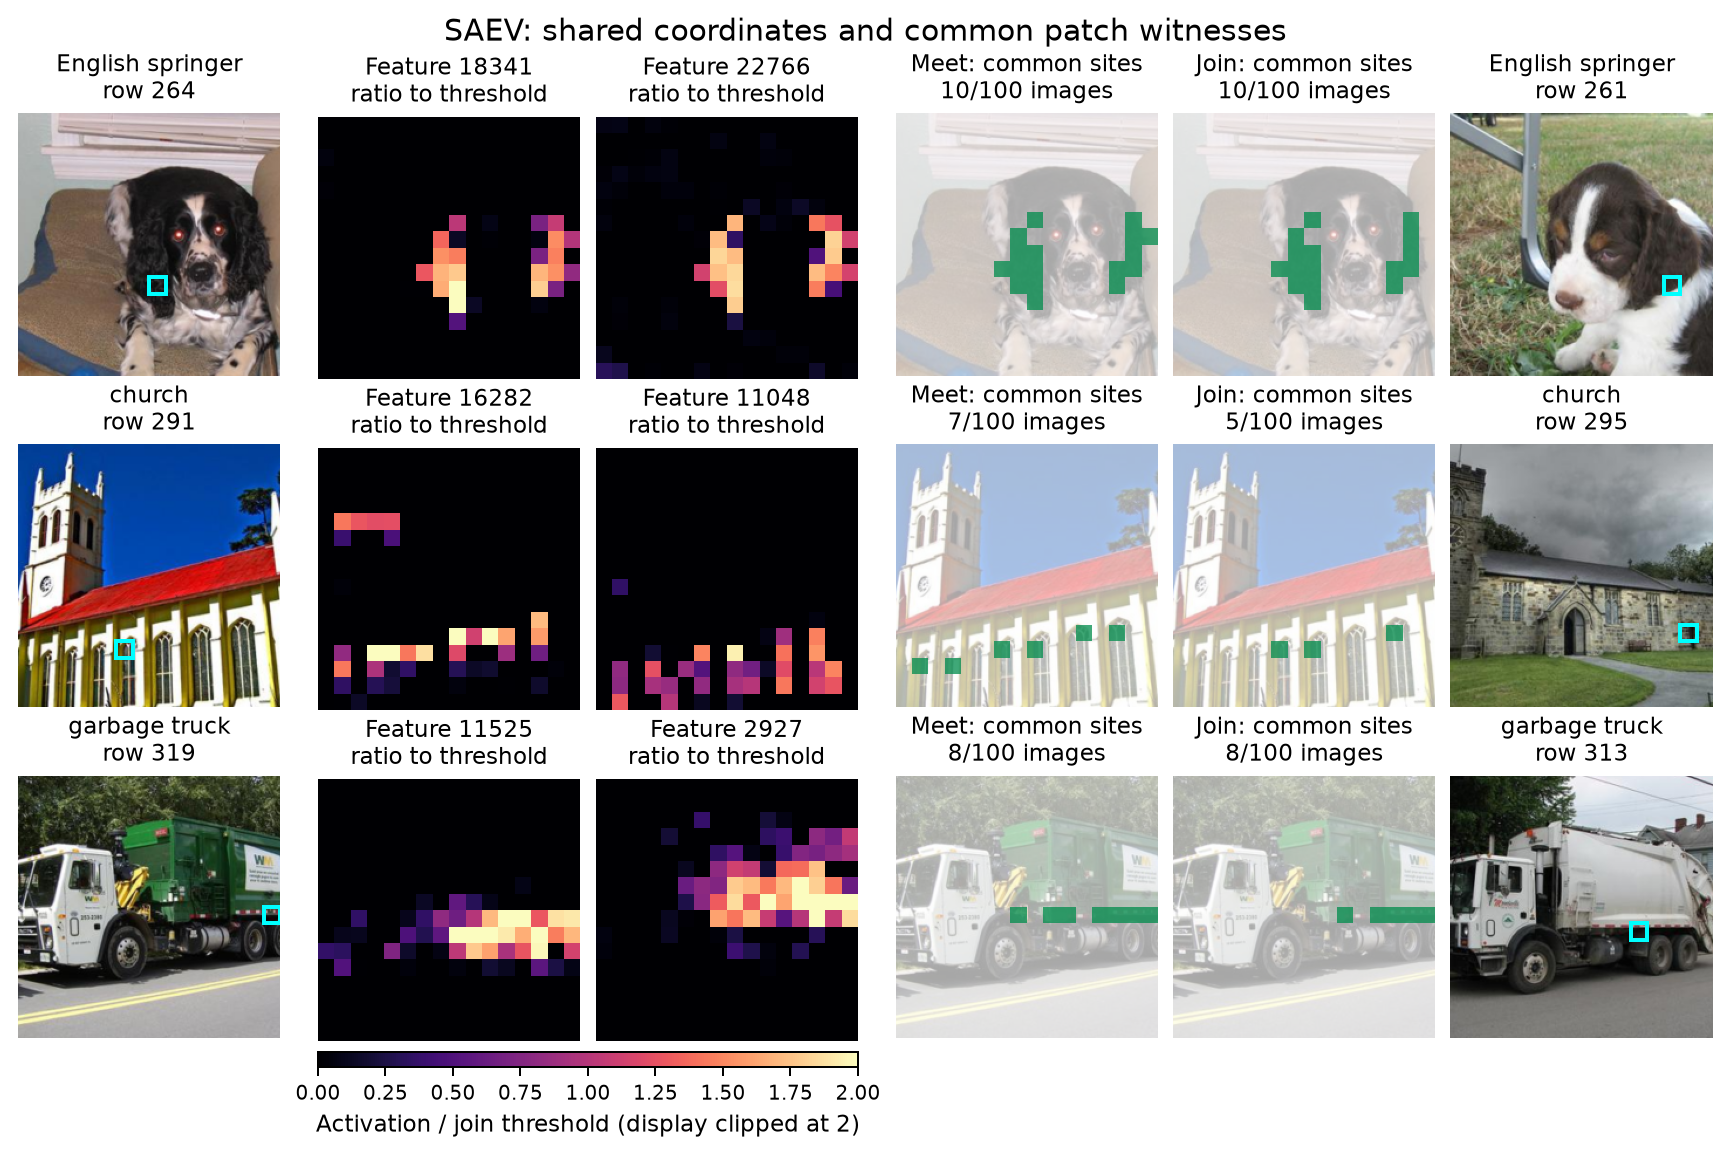

In [3]:
from IPython.display import Image, display
def show(name, kind):
    folder = evidence / name / 'figures'
    display(Image(filename=str(folder /
        f'{name}_patch_{kind}_codexgen.png')))
for name in ['prisma', 'saev']:
    show(name, 'gallery')

## Closed downset descriptions

Shaded rectangles are principal downsets; their union is the
exact intersection of two source-image descriptions in two
selected coordinates. Multiple maximal generators cannot be
replaced by their coordinatewise maximum without changing
the description. Exact closure is often too restrictive to
retrieve new test photographs; this is recorded, not hidden.

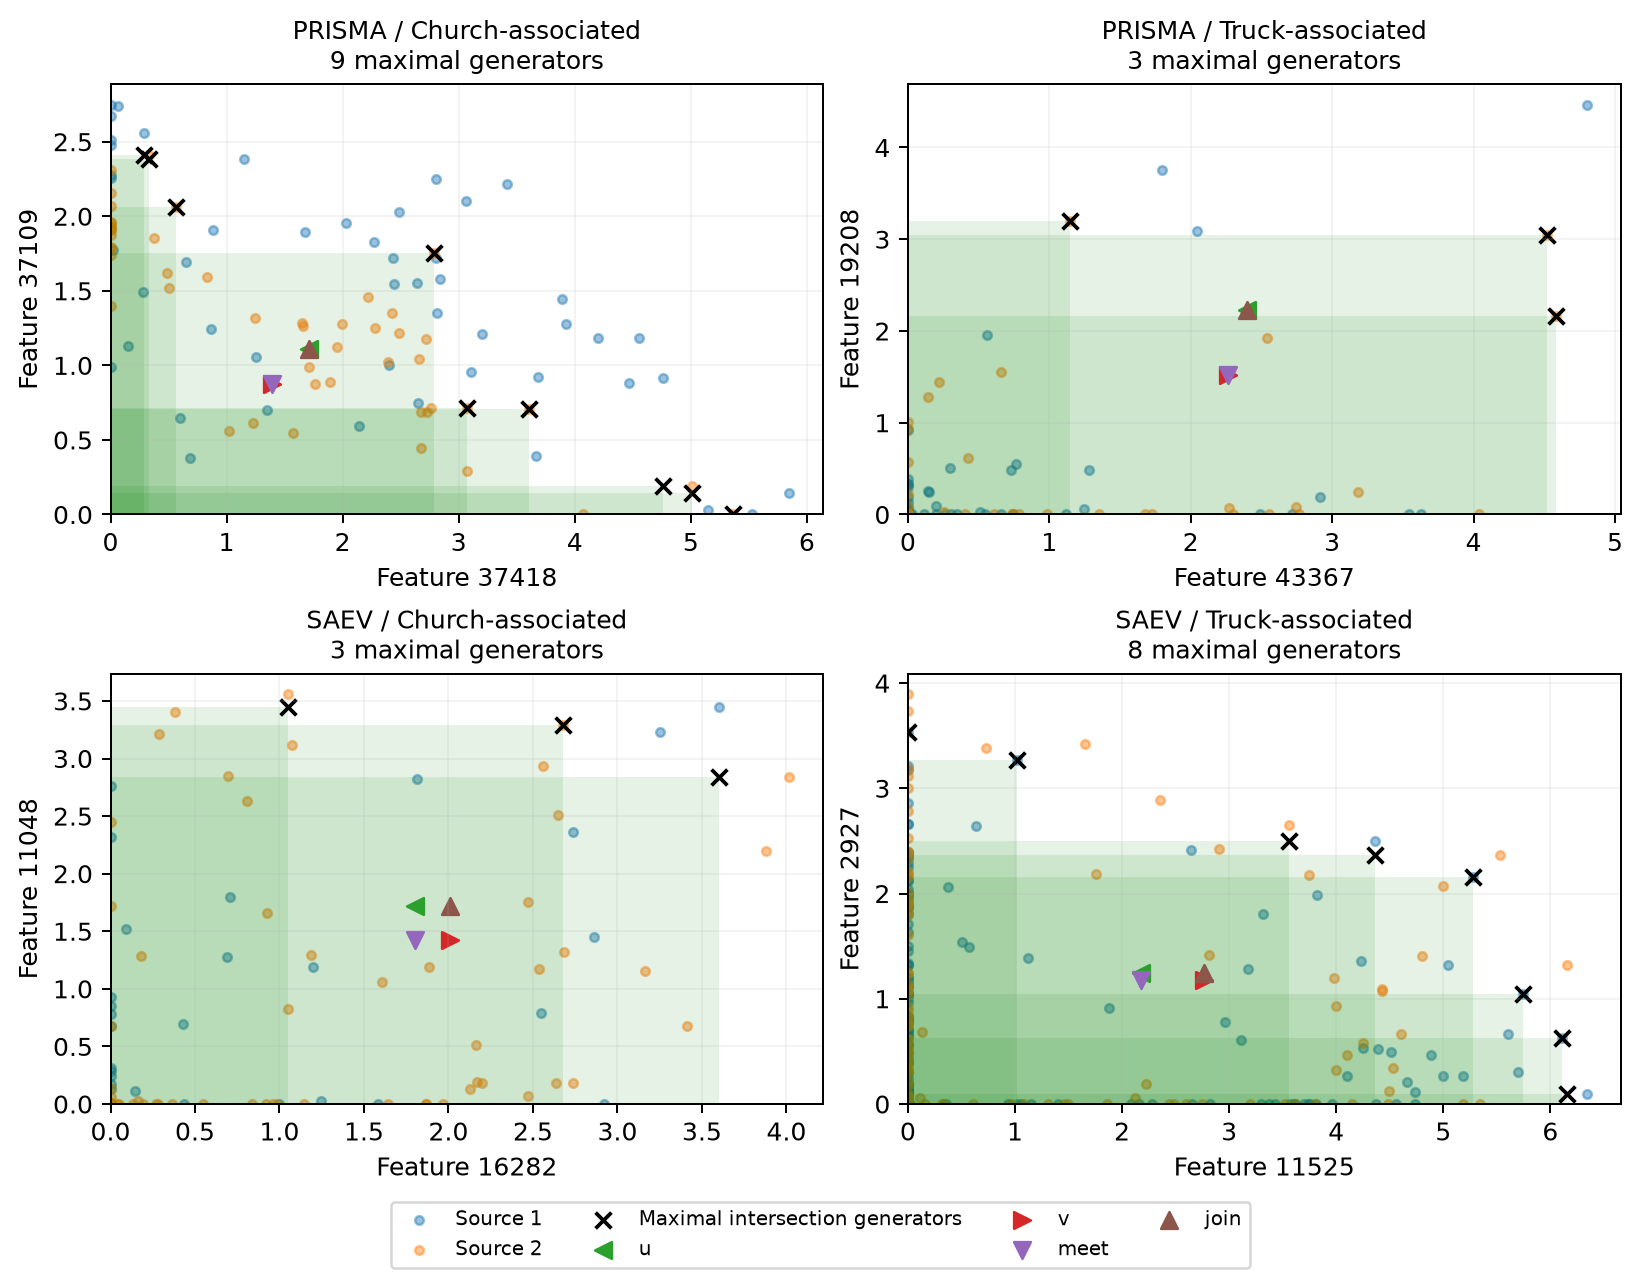

prisma tench join pooled / same-site 10 10 generators 3
prisma English springer join pooled / same-site 8 8 generators 1
prisma cassette player join pooled / same-site 5 2 generators 2
prisma chain saw join pooled / same-site 6 0 generators 3
prisma church join pooled / same-site 9 6 generators 9
prisma French horn join pooled / same-site 6 6 generators 1
prisma garbage truck join pooled / same-site 10 3 generators 3
prisma gas pump join pooled / same-site 19 3 generators 3
prisma golf ball join pooled / same-site 7 7 generators 1
prisma parachute join pooled / same-site 6 6 generators 2
saev tench join pooled / same-site 9 9 generators 2
saev English springer join pooled / same-site 10 10 generators 2
saev cassette player join pooled / same-site 11 3 generators 11
saev chain saw join pooled / same-site 8 0 generators 4
saev church join pooled / same-site 6 5 generators 3
saev French horn join pooled / same-site 6 6 generators 1
saev garbage truck join pooled / same-site 10 8 generator

In [4]:
show('prisma', 'downsets')
for name in ['prisma', 'saev']:
    path = evidence / name / 'results/contexts_codexgen.json'
    for case in json.loads(path.read_text())['cases']:
        print(name, case['class'], 'join pooled / same-site',
              case['pooled_test'][3],
              case['same_site_test'][3], 'generators',
              case['downset_generators'])

## Identical pixels, different context

Each row preserves its marked patch pixels exactly. The
joint score is at that designated site and must reach one
to satisfy the join. Gray ablations are out of distribution;
this is a limited context-dependence test, not evidence that
a discovered circuit uses a particular semantic shape.

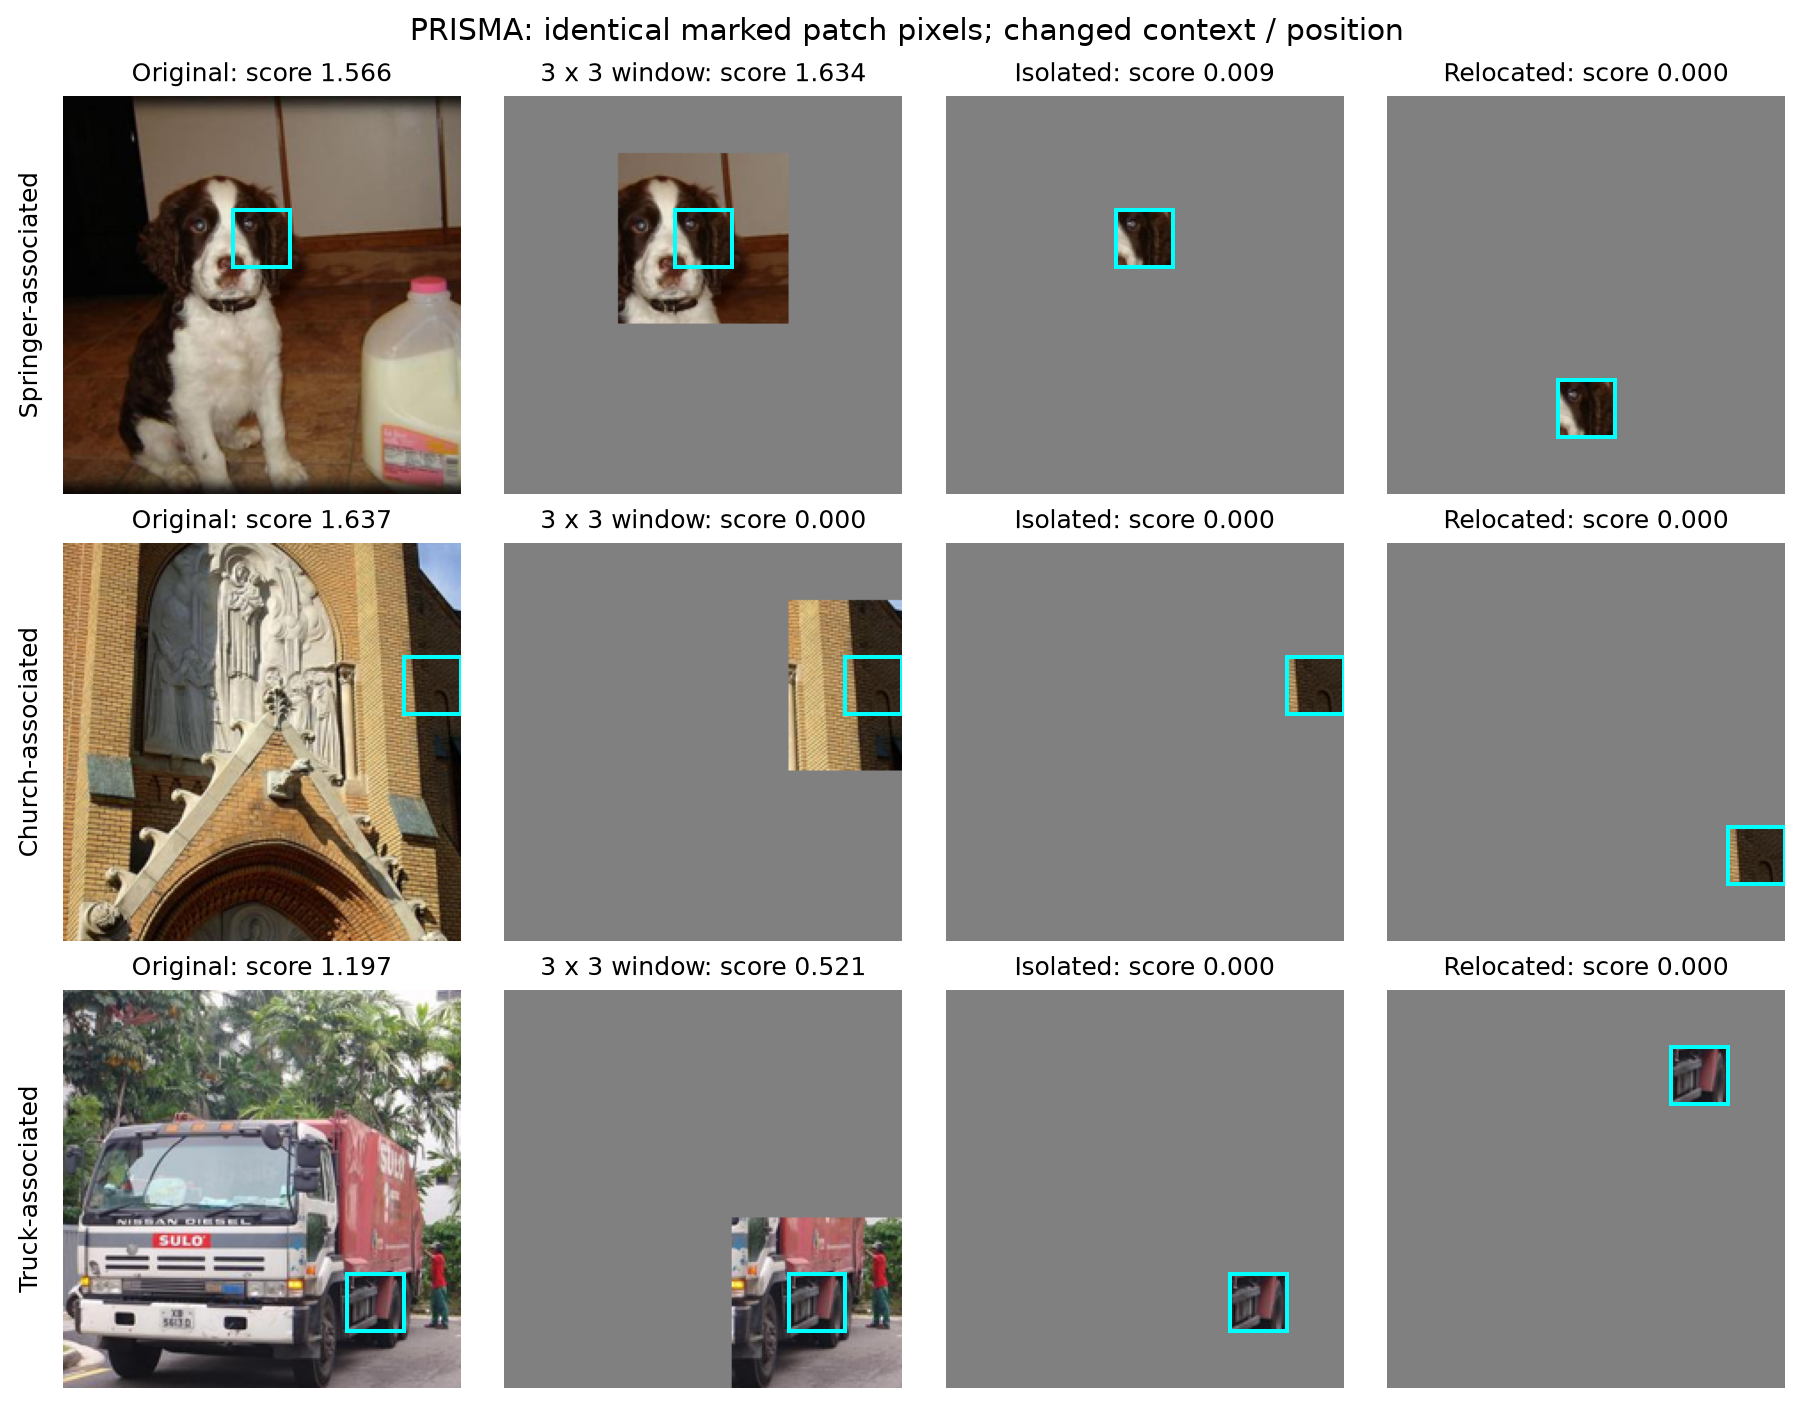

{
  "flip": [
    {
      "class_id": 0,
      "mean_jaccard": 0.7986111111111112,
      "nonempty_union_images": 10,
      "shuffled_mean": 0.050349478299478306,
      "shuffled_quantiles": [
        0.015226190476190476,
        0.13664102564102543
      ]
    },
    {
      "class_id": 1,
      "mean_jaccard": 0.6413690476190477,
      "nonempty_union_images": 8,
      "shuffled_mean": 0.03213000541125541,
      "shuffled_quantiles": [
        0.0,
        0.12203124999999994
      ]
    },
    {
      "class_id": 2,
      "mean_jaccard": 0.5,
      "nonempty_union_images": 4,
      "shuffled_mean": 0.031094537815126052,
      "shuffled_quantiles": [
        0.0,
        0.07142857142857142
      ]
    },
    {
      "class_id": 3,
      "mean_jaccard": 0.0,
      "nonempty_union_images": 1,
      "shuffled_mean": 0.0,
      "shuffled_quantiles": [
        0.0,
        0.0
      ]
    },
    {
      "class_id": 4,
      "mean_jaccard": 0.7152777777777777,
      "nonempty_union_image

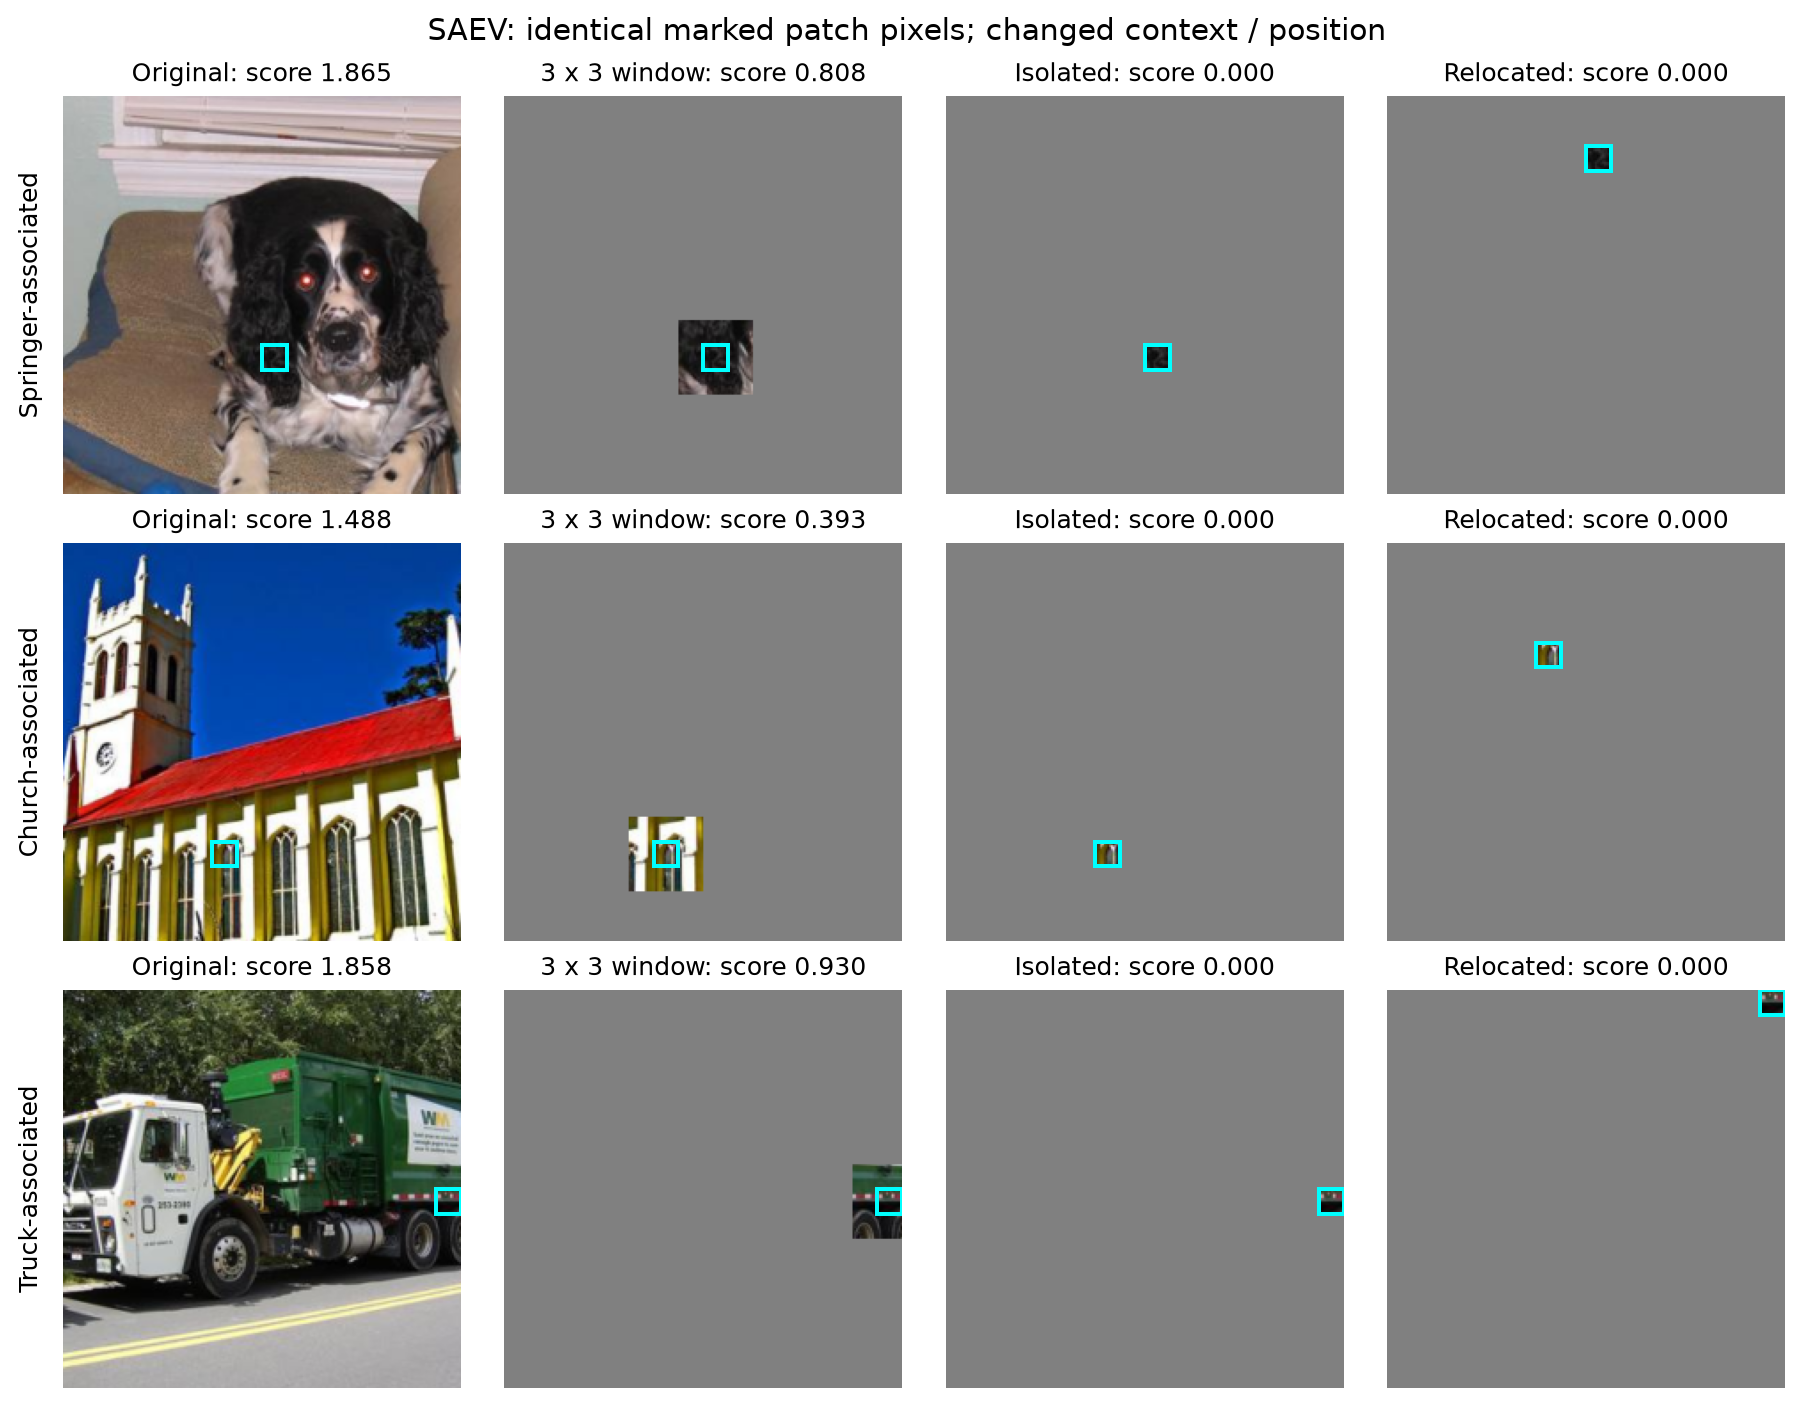

{
  "flip": [
    {
      "class_id": 0,
      "mean_jaccard": 0.6946428571428571,
      "nonempty_union_images": 10,
      "shuffled_mean": 0.008644250194250193,
      "shuffled_quantiles": [
        0.0,
        0.036081349206349145
      ]
    },
    {
      "class_id": 1,
      "mean_jaccard": 0.501304347826087,
      "nonempty_union_images": 10,
      "shuffled_mean": 0.014400271287025403,
      "shuffled_quantiles": [
        0.002325581395348837,
        0.03738961547790064
      ]
    },
    {
      "class_id": 2,
      "mean_jaccard": 0.42142857142857143,
      "nonempty_union_images": 4,
      "shuffled_mean": 0.017920766254499204,
      "shuffled_quantiles": [
        0.0022405660377358494,
        0.04393617021276585
      ]
    },
    {
      "class_id": 3,
      "mean_jaccard": null,
      "nonempty_union_images": 0,
      "shuffled_mean": null,
      "shuffled_quantiles": null
    },
    {
      "class_id": 4,
      "mean_jaccard": 0.45,
      "nonempty_union_images": 5,

In [5]:
for name in ['prisma', 'saev']:
    show(name, 'controls')
    path = evidence / name / 'results/controls_codexgen.json'
    print(json.dumps(json.loads(path.read_text()), indent=2))

## Reproduce

See `vision_tokens/patch_contexts/README.md` for pinned sources,
environment setup, native checks, checkpoint reassembly, and
rerun commands. No paper files are required. Reflection results
use within-image shuffled positions as a descriptive reference,
not a confidence interval over a new image population.